# Exercise 2: Calculate degassing paths

In this exercise we will calculate degassing paths applicable to the 2018 Lower East Rift Zone eruption of Kı̄lauea and compare it to melt and fluid inclusion data (Wieser et al., 2021; DeVitre & Wieser, 2024) using the tools VESIcal (Iacovino et al., 2021), VolFe (Hughes et al., 2025), Sulfur_X (Ding et al., 2023), and Evo (Liggins et al., 2020, 2022) through the VICTOR platform (Lev et al., 2025) or locally if the required packages are installed. Other tools are available for these types of calculations (e.g., D-Compress - Burgisser et al. 2015; CHOSETTO - Moretti and Ottonello 2003, Moretti and Papale 2004; MAGEC - Sun and Lee 2022, Sun and Yao 2024) but we have chosen options available entirely through VICTOR.

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b>🐣 &nbsp; To run locally</b><br> See the notebook <b><a href="0_Getting_Started.ipynb">0. Getting Started</a></b>. Always remember to ensure this notebook is running in the volatiles-gs-workshop26 conda environment!

<em>If you are running this on the VICTOR platform, all packages are already installed and you can skip this step. More information on VICTOR can be found at <a href="https://docs.victorproject.org/en/latest/index.html">https://docs.victorproject.org/en/latest/index.html</em></a>
</div>

## 1. Introduction
### 1.1 Import packages and note versions

In [ ]:
# Packages that we will use in our code always get imported before we need them.
# This is canonically done at the top of a script.
# ⚠️ Note that this can take a few seconds if it's the first time you're importing these libraries.

import pandas as pd
import matplotlib.pyplot as plt
import VolFe as vf
import VESIcal as vc
import DiadFit as pf
import evo

c:\Users\penny\anaconda3\envs\volatiles-gs-workshop26\Lib\site-packages\VESIcal\calculate_classes.py:7: UserWarning: 

  from VESIcal.models import magmasat


When reporting calculations in manuscripts, it's important to know which version of the Python package the results you are showing used - so we can output those below. This notebook was created using VolFe: 1.0.2 , VESIcal: 1.2.12 , Thermobar: 1.0.73 , pandas: 2.2.3, EVo: 1.1.0 (at git sha 2487939e18d98292f9b8f3a1f0dea04b707bd89f), and Sulfur_X 1.2 (git sha d605a34135c906c00f26de77b7e7f9abdb05d86f).

In [4]:
print(
    f"VolFe: {vf.__version__}",
    f"\nVESIcal: {vc.__version__}"
    f"\npandas: {pd.__version__}",
    f"\nDiadFit: {pf.__version__}",
    )

VolFe: 1.0.3 
VESIcal: 1.2.12
pandas: 3.0.3 
DiadFit: 1.0.23


### 1.2 Import data

We'll use the same melt inclusion dataset from notebook <a href="1_Calculate_Pressure_and_Fluid_Compositions.ipynb">1_Calculate_Pressure_and_Fluid_Compositions.ipynb</a>

In [ ]:
# import melt inclusion dataset
MI = pd.read_csv("files/wieser2021_w_temperatures.csv")

## 2. Initial melt composition

We choose the MI with the highest CO2 content as the starting point for the degassing calcuations

In [71]:
# row number with highest CO2 content
row = MI['CO2'].idxmax()

print(f"The sample with the highest CO2 content is {row} with {MI['CO2'][row]} wt%")

The sample with the highest CO2 content is 4 with 0.1405 wt%


We also specify the initial <i>f</i>O<sub>2</sub> (ΔFMQ = 0.2 as before) and H<sub>2</sub>O = 0.5 wt%

In [72]:
DFMQ = 0.2
H2Oi = 0.5 # wt%

And combine this all into a single dictionary to use

In [ ]:
ini_comp = MI.loc[row].to_dict()
ini_comp = {k.split(" ")[0]: v for k, v in ini_comp.items()}
ini_comp.update({
    "H2O": H2Oi,
    'DFMQ': DFMQ
})

# print initial composition
ini_comp

{'Unnamed:': 4,
 'number': 53,
 'T_C': 1169.775,
 'type': 'MI',
 'Sample': 'LL4_13',
 'Specific': 'Fissure 8 (May 30th)',
 'Na2O': 2.65,
 'Al2O3': 0.03,
 'P2O5': 0.16,
 'CaO': 0.24,
 'K2O': 0.5,
 'TiO2': 2.97,
 'SiO2': 39.26,
 'MgO': 42.57,
 'FeO': 17.08,
 'MnO': 0.23,
 'H2O': 0.5,
 'Total': 1405.0,
 'S_MI_PEC': 975.9054348,
 'Fo': 0.82,
 'NiO': 0.25,
 'CO2': 0.1405,
 'DFMQ': 0.2}

## 3. Calculate degassing path

Now we'll calculate degassing paths using various tools. In all our calculations we will assume closed-system degassing, but open-system degassing calculations are possible with all these tools. Additionally we'll assume isothermal (i.e., single temperature), no crystallisation, and that there is only melt at the beginning of the degassing path (i.e., no additional vapor).

### 3.1 VESIcal

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; VESIcal </b> is a framework for thermodynamic modeling of magmatic volatiles written in Python - an open-source volatile solubility engine.

More information on VESIcal can be found at https://vesical.readthedocs.io/en/latest/

</div>

For consistency with the previous notebook, we'll use the same model options as before (``"IaconoMarziano"``), but these can be changed! See Section 3.1 in <a href="1_Calculate_Pressure_and_Fluid_Composition.ipynb">1. Calculate pressure and fluid composition</a> or the VESIcal ReadTheDocs for more info.

In [ ]:
# create VESIcal sample from ini_comp
ini_comp_wtpt = {key: val for key, val in ini_comp.items() if key in vc.oxides}
sample_vc = vc.Sample(ini_comp_wtpt)
# sample_vc.get_composition() # print composition if so desired

In [75]:
# run calculation
# temperature is specified in the function
results_degas_vc = vc.calculate_degassing_path(
    sample=sample_vc,
    temperature=float(MI.loc[row,'T_C']), # temperatures calculated by Thermobar in notebook 1
    model="IaconoMarziano").result

# save your results
results_degas_vc.to_csv("output/results_degas_vc.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_degas_vc

### 3.2 VolFe

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; VolFe </b> is an open-source Python package for calculating melt-vapor equilibra in the CHOS+ system, including concentration, speciation, and isotope ratios.

More information on VolFe can be found at https://volfe.readthedocs.io/en/latest/

</div>

VolFe requires additional inputs to VESIcal (S and <i>f</i>O<sub>2</sub>). Again, we'll use the same model options as before, but these can be changed if required - see Section 3.2 in <a href="1_Calculate_Pressure_and_Fluid_Composition.ipynb">1. Calculate pressure and fluid composition</a> or the VolFe ReadTheDocs for more info.

In [ ]:
# Define initial melt composition
sample_vf = ini_comp.copy()
sample_vf["CO2ppm"] = sample_vf.pop("CO2")*10**4 # convert to ppm
sample_vf["STppm"] = sample_vf.pop("S_MI_PEC")
sample_vf["Sample"] = sample_vf.pop('Unnamed:')

sample_vf = pd.DataFrame(sample_vf, index=[0])

# define models
models_vf = [['water','Basalt_Hughes24'],['carbon dioxide','MORB_Dixon95'],['sulfide','ONeill21dil'],['sulfate','ONeill22dil']]
models_vf = vf.make_df_and_add_model_defaults(models_vf)

In [79]:
# run calculation
results_degas_vf = vf.calc_gassing(sample_vf, models = models_vf)

# save your results
results_degas_vf.to_csv("output/results_degas_vf.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_degas_vf

c:\Users\penny\anaconda3\envs\volatiles-gs-workshop26\Lib\site-packages\VolFe\melt_gas.py:2059: UserWarning: you entered more than one way to infer iron speciation, note that this calcualtion is only considering the entered DFMQ
  w.warn(
  0%|          | 0/1 [00:00<?, ?it/s]


### 3.3 Sulfur_X

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; Sulfur_X </b> is a model of sulfur degassing during magma ascent.

More information on Sulfur_X can be found at https://github.com/sdecho/Sulfur_X

</div>

We can also run degassing calculations with Sulfur_X, which like VolFe includes S.

This example has been modified from VICTOR.

First we have to define the directory where Sulfur_X is hosted

In [80]:
SulfurX_directory = 'Sulfur_X-main/'

Next we define the initial melt composition. We won't use it today, but the sulfide composition can be defined as well as the sulfur isotope ratio (these can also be used in VolFe). If crystallisation is required, this should also be defined - we are not using this option today.

In [ ]:
# Temperature in C
temperature = round(float(MI.loc[row,'T_C']))

# fO2 relative to FMQ buffer
delta_FMQ = DFMQ

# initial H2O in wt.%
H2O_initial = ini_comp['H2O']

# initial CO2 in ppm
CO2_initial = round(ini_comp['CO2']*10**4)

# initial sulfur in ppm
S_initial = float(MI.loc[row,'S_MI_PEC EPMA'])

# melt composition
sio2 = float(ini_comp['SiO2'])
al2o3 = float(ini_comp['Al2O3'])
feot = float(ini_comp['FeO'])
mgo = float(ini_comp['MgO'])
cao = float(ini_comp['CaO'])
na2o = float(ini_comp['Na2O'])
k2o = float(ini_comp['K2O'])
p2o5 = float(ini_comp['P2O5'])
mno = float(ini_comp['MnO'])
tio2 = float(ini_comp['TiO2'])

# Options below are NOT being used in the example today
# Sulfide composition in wt%, only relevant if SCSS is of interest. 
sulfide = {"Fe": 65.43,
            "Ni": 0,
            "Cu": 0,
            "O": 0,
            "S": 36.47
            }
# initial sulfur isotope ratio
d34s_m_initial = 1
# if crystallization is enabled, H2O-melt fraction relation is specified using H2O-K2O relation (K2O = a * H2O +b),
# assuming K2O is perfectly incompatible. The given a and b are based on H2O-K2O relation for Fuego magma from
# Lloyd et al. (2013). Both H2O and K2O are in wt.%. If crystallization is disabled, or running on magmas similar to Fuego,
# leave them unchanged.
slope_h2o = -0.713
constant_h2o = 3.689

These parameters effect how the calculation is performed - more information on these can be found on the Sulfur_X GitHub.

In [104]:
# The total steps of pressure from initial P to 1 bar.
l = 1000

# Total number of runs along degassing
m = 1000

# Pressure threshold (in bar) below which the Kd_combined can increase with an arbiturary number defined by INC
BAR = 0

# Arbiturary increase of Kd_combined when pressure is lower than BAR (in bar) when BAR > 0; if BAR = 0, INC is not relevant
INC = 20

# Tolerance (sigma) of log_10(fO2)
sigma = .01

As with the other tools, Sulfur_X has different model options available, which can be chosen using the following parameters. Here we'll use the CO<sub>2</sub>-H<sub>2</sub>O solubility of Iacono-Marziano et al. (2012) to match the VESIcal calculations and the S speciation model of O'Neil & Mavrogenes (2022) to match the VolFe calculations. Crystallisation and sulfide precipitation are turned off and the calculations are closed-system degassing. We do not perform Monte Carlo simulations.

In [ ]:
# Which COH degassing model to use? 1 for VolatileCalc; 0 for Iacono_Marziano model
COH_model = 0

# Which S speciation model to use? 0 for Nash model; 1 for O'Neill and Mavrogenes (2022) model; 100 for Muth model
S_Fe_choice = 1

# The options below are NOT being changed for this calculation
# Changing fO2 or not? If 1, fO2 changes by S degassing and S-Fe electron exchange;
# if 0, fO2 if buffered at the delta_FMQ
fo2_tracker = 1
# Enable crystallization (yes=1,no=0)
crystallize = 0
# sulifde saturation: if 0, no sulfide precipitation; if 1, sulfide precipitation enabled
sulfide_pre = 0
# Use monte carlo simulation for error estimate? (1/0)
# If 1, input number of runs, otherwise ignore
monte_carlo = 0
mc_runs = 0
# Decimal value between 0 and 1, percentage of melt; initial value to start the calculation. 
melt_fraction = 1
# degassing style: if 0, fully closed degassing; if x, degassing become open when pressure is lower than xMPa
open_degassing = 0

These final options are about where the data are saved to and where MI data are taken to for plotting.

In [ ]:
# prepare MI file
MI_sfx = MI.copy()
MI_sfx = MI_sfx.rename(columns = {"CO2_ppm":"mi_CO2","S":"mi_S","H2O":"mi_H2O","SaturationP_bars_VESIcal":"pressure"})
MI_sfx.to_csv(SulfurX_directory+'Kilauea.csv')

# Melt inclusion data file (.csv) Sulfur_X can read in MI file (template shown by Fuego.csv) for comparison. Here we will use the Kilauea file that we have been working on instead.
mi_name = SulfurX_directory+"Kilauea.csv"

# Output path
output_path = SulfurX_directory+'results_folder'

#Save plot images? (True/False)
save_img = False

Finally, we input all these values into the .py files to run the calculation.

In [108]:
f = open(SulfurX_directory+"main_Fuego.py","r+")
main = f.readlines()
main[32] = f"""temperature = {temperature}\n"""
main[35] = f"""delta_FMQ = {delta_FMQ}\n"""
main[37] = f"""H2O_initial = {H2O_initial}\n"""
main[39] = f"""CO2_initial = {CO2_initial}\n"""
main[41] = f"""S_initial = {S_initial}\n"""
main[43] = f"""d34s_m_initial = {d34s_m_initial}\n"""
main[45] = f"""choice = {crystallize}\n"""
main[47] = f"""COH_model = {COH_model}\n"""
main[50] = f"""fo2_tracker = {fo2_tracker}\n"""
main[54] = f"""monte_carlo = {monte_carlo}\n"""
main[57] = f"""    m_run = {mc_runs}\n"""
main[63] = f"""l = {l}\n"""
main[65] = f"""m = {m}\n"""
main[68] = f"""sulfide = {{"Fe": {sulfide["Fe"]},\n"""
main[69] = f"""         "Ni": {sulfide["Ni"]},\n"""
main[70] = f"""         "Cu": {sulfide["Cu"]},\n"""
main[71] = f"""         "O": {sulfide["O"]},\n"""
main[72] = f"""         "S": {sulfide["S"]},\n"""
main[75] = f"""open_degassing = {open_degassing}\n"""
main[77] = f"""sulfide_pre = {sulfide_pre}\n"""
main[85] = f"""S_Fe_choice = {S_Fe_choice}\n"""
main[88] = f"""sigma = {sigma}\n"""
main[94] = f"""slope_h2o = {slope_h2o}\n"""
main[95] = f"""constant_h2o = {constant_h2o}\n"""
main[102] = f"""mi_name = '{mi_name}'\n"""
main[107] = f"""folder = Path("{output_path}")\n"""
f.seek(0)
f.writelines(main)
f.truncate()
f.close()

g = open(SulfurX_directory+"degassingrun.py","r+")
degas = g.readlines()
degas[13] = f"""INC = {INC}\n"""
degas[14] = f"""BAR = {BAR}\n"""
degas[35] = f"""        self.sulfide = {{"Fe": {sulfide["Fe"]},\n"""
degas[36] = f"""                        "Ni": {sulfide["Ni"]},\n"""
degas[37] = f"""                        "Cu": {sulfide["Cu"]},\n"""
degas[38] = f"""                        "O": {sulfide["O"]},\n"""
degas[39] = f"""                        "S": {sulfide["S"]},\n"""
g.seek(0)
g.writelines(degas)
g.truncate()
g.close()

g = open(SulfurX_directory+"melt_composition.py","r+")
melt_comp = g.readlines()
melt_comp[76] = f"""            sio2 = {sio2} / melt_fraction\n"""
melt_comp[77] = f"""            al2o3 = {al2o3} / melt_fraction\n"""
melt_comp[78] = f"""            feot = {feot} / melt_fraction\n"""
melt_comp[79] = f"""            mgo = {mgo} / melt_fraction\n"""
melt_comp[80] = f"""            cao = {cao} / melt_fraction\n"""
melt_comp[81] = f"""            na2o = {na2o} / melt_fraction\n"""
melt_comp[82] = f"""            k2o = {k2o} / melt_fraction\n"""
melt_comp[83] = f"""            p2o5 = {p2o5} / melt_fraction\n"""
melt_comp[84] = f"""            mno = {mno} / melt_fraction\n"""
melt_comp[85] = f"""            tio2 = {tio2} / melt_fraction\n"""
g.seek(0)
g.writelines(melt_comp)
g.truncate()
g.close()

And run the calculation! Make sure the path is correct here...

 The initial vapor saturation pressure is 551.4357963307718 bar, and the initial vapor concentration is XH2O = 0.0034476032844308704 and XCO2 = 0.9965523967155692.
Final pressure = 0.1
The initial Ferric iron ratio is 0.13354081974520896
The initial sulfate ratio in the melt is 0.032511147806870255
Montecarlo simulation


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


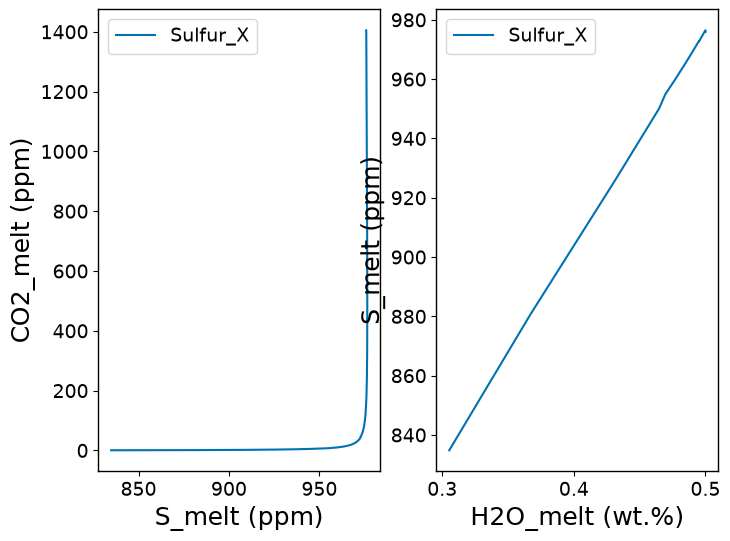

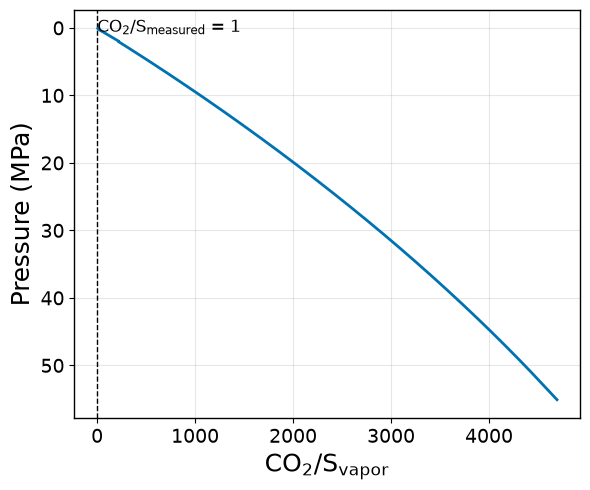

In [109]:
%run Sulfur_X-main/main_Fuego.py

In [ ]:
# load results from where they are saved
results_degas_sx = pd.read_csv('Sulfur_X-main/results_folder/test_Fuego_closedT'+str(temperature)+'_dFMQ'+str(delta_FMQ)+'_H2O'+str(H2O_initial)+'_CO2'+str(CO2_initial)+'_fO2track.csv')

# save your results
results_degas_sx.to_csv("output/results_degas_sfx.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_degas_sfx

### 3.4 EVo

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; EVo </b> is a thermodynamic magma degassing model.

More information on EVo can be found at https://evo-outgas.readthedocs.io/en/latest/index.html

</div>

We can also run degassing calculations with EVo, which like VolFe and Sulfur_X, also includes S.

This example has been modified from the EVo worked example (https://github.com/pipliggins/EVo/tree/main/examples)

First we define the melt composition

In [111]:
composition = pd.Series(
    {
        "SIO2": float(ini_comp['SiO2']),
        "TIO2": float(ini_comp['TiO2']),
        "AL2O3": float(ini_comp['Al2O3']),
        "FEO": float(ini_comp['FeO']),
        "MNO": float(ini_comp['MnO']),
        "MGO": float(ini_comp['MgO']),
        "CAO": float(ini_comp['CaO']),
        "NA2O": float(ini_comp['Na2O']),
        "K2O": float(ini_comp['K2O']),
        "P2O5": float(ini_comp['P2O5']),
    }
)

This configures the run for EVo. Like the other tools, EVo has different options for the volatile solubility laws. Here, we'll use the options appropriate for a basaltic composition, but more details are available in EVo's ReadTheDocs. More information on these options can be found on EVo's GitHub https://github.com/pipliggins/EVo

In [ ]:
# Set up fixed model parameters
model = {
    "COMPOSITION": "basalt", # specify the appropriate solubility functions - other options are phonolite or rhyolite
    "FIND_SATURATION": True, # If `True`, EVo finds the volatile saturation pressure and decompresses from there
    "GAS_SYS": "cohs", # Volatile system to model: `oh`, `coh`, `soh`, `cohs`, `cohsn`
    "FE_SYSTEM": True, # If `True`, fO2 is buffered by melt Fe2+/Fe3+ exchange
    "FO2_buffer_SET": True, # Toggle option to set the initial fO2 using a value relative to a rock buffer (either IW, FMQ or NNO)
    "FH2_SET": False, # Toggle using hydrogen fugacity as a starting condition on/off, and set the starting value.
    "WTH2O_SET": True, # Toggle using water content in the melt as a starting condition on/off
    "WTCO2_SET": True, # Toggle using carbon dioxide content in the melt as a starting condition on/off
    "SULFUR_SET": True, # Toggle using sulfur content in the melt as a starting condition on/off
}

And then we merge the input and model parameters for EVo

In [113]:
env = pd.Series(
    model
    | {
        "FO2_buffer": "FMQ", # Rock buffer (`IW`, `FMQ`, `NNO`) and log-unit offset 
        "FO2_buffer_START": DFMQ, # ... and log-unit offset
        "T_START": float(MI.loc[row,'T_C']) + 273.15+10, # Temperature in Kelvin
        # Volatile inputs as melt wt fractions (EVo uses wt fraction internally)
        "WTH2O_START": ini_comp['H2O'] / 100,
        "WTCO2_START": ini_comp['CO2'] / 100,
        "SULFUR_START": ini_comp['S_MI_PEC'] / 1e6,
    }
)

And then we run the calculation!

In [114]:
# run calculation
results_degas_evo = evo.run_evo(composition, env)

# save your results
results_degas_evo.to_csv("output/results_degas_evo.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_degas_evo

Reading in from:
Output file: None 

Would you like to switch to the Righter et al. (2013) fO2 model? [Y]/n 


Are you sure you want to continue? y/[N] Set parameters:
COMPOSITION = basalt
RUN_TYPE = closed
SINGLE_STEP = False
FIND_SATURATION = True
GAS_SYS = COHS
FE_SYSTEM = True
OCS = False
S_SAT_WARN = False
T_START = 1452.9250000000002
P_START = 3000.0
P_STOP = 1.0
DP_MIN = 1.0
DP_MAX = 100.0
MASS = 100.0
WgT = 0.001
LOSS_FRAC = 0.99
DENSITY_MODEL = spera2000
FO2_MODEL = r2013
FMQ_MODEL = frost1991
H2O_MODEL = burguisser2015
H2_MODEL = gaillard2003
C_MODEL = burguisser2015
CO_MODEL = None
CH4_MODEL = None
SULFIDE_CAPACITY = oneill2020
SULFATE_CAPACITY = nash2019
SCSS = liu2007
N_MODEL = libourel2003
FO2_buffer_SET = True
FO2_buffer = FMQ
FO2_buffer_START = 0.2
FO2_SET = True
FO2_START = 0.0
FH2_SET = False
FH2_START = 0.24
FH2O_SET = False
FH2O_START = 1000.0
FCO2_SET = False
FCO2_START = 0.01
ATOMIC_MASS_SET = False
ATOMIC_H = 550.0
ATOMIC_C = 200.0
ATOMIC_S = 4000.0
ATOMIC_N = 10

c:\Users\penny\anaconda3\envs\volatiles-gs-workshop26\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `<class 'pathlib.PosixPath'>` but got `<class 'pathlib.WindowsPath'>` with value `'outputs'` - serialized value may not be as expected.)
  return self.__pydantic_serializer__.to_python(


0.02953762709053649 2.67240836565607e-05 2.7912770913238085e-12 1628.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.02953698394528876 2.6743999651358667e-05 2.7933997287748537e-12 1627.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.029536340649929577 2.6763939545785632e-05 2.795524944113898e-12 1626.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.029535697203257126 2.678390338337346e-05 2.7976527420646882e-12 1625.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.029535053604069314 2.6803891207756035e-05 2.7997831273621457e-12 1624.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.02953440985116054 2.682390306267585e-05 2.8019161047529883e-12 1623.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.029533765943324755 2.6843938991978028e-05 2.804051678995201e-12 1622.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.029533121879350723 2.686399903962049e-05 2.8061898548590052e-12 1621.0 End of a pressure step!!!!!!!!!!!!!!!!!!!!!!
0.029532477658030527 2.6884083249657566e-05 2.808330637125

## 4. Plot and compare to data

We can now plot the different degassing calculations and compare the MI and FI data! 

Let's import the saturation pressure results calculated in <a href="1_Calculate_Pressure_and_Fluid_Composition.ipynb">1. Calculate pressure and fluid composition</a>

In [ ]:
# import FI data and calculate SO2/(CO2+SO2) ratio
df_FI = pd.read_excel("data/Kilauea_MI_FI_MG_data.xlsx", sheet_name='FI_Data')
df_FI['SO2_Burke_table_pref']=pf.calculate_SO2_CO2_mol_prop_wave_indep(SO2_wavelength_ind=4.03, CO2_diad1_wavelength_ind=0.8, CO2_diad2_wavelength_ind=1.23, wavelength_nm=532.046,T_C=37,
                               A_SO2=df_FI['SO2_Area'], A_CO2_Tot=(df_FI['ν1_Voigt_Area']+ df_FI['2ν2_Voigt_Area']))

# import MI and FI results calculated in Exercise 1
results_pvsat_vc = pd.read_csv("output/results_pvsat_vc.csv")
results_pvsat_vf = pd.read_csv("output/results_pvsat_vf.csv")
results_P_df = pd.read_csv("output/results_P_df.csv")

# if you haven't run Exercise 1, you can grab the "answer key" file from here:
#results_pvsat_vc = pd.read_csv("files/results_pvsat_vc.csv")
#results_pvsat_vf = pd.read_csv("files/results_pvsat_vf.csv")
#results_P_df = pd.read_csv("files/results_P_df.csv")

# if you haven't run this Exercise, you can grab the "answer key" files from here:
#results_degas_vc = pd.read_csv("files/results_degas_vc.csv")
#results_degas_vf = pd.read_csv("files/results_degas_vf.csv")
#results_degas_sfx = pd.read_csv("files/results_degas_sfx.csv")
#results_degas_evo = pd.read_csv("files/results_degas_evo.csv")

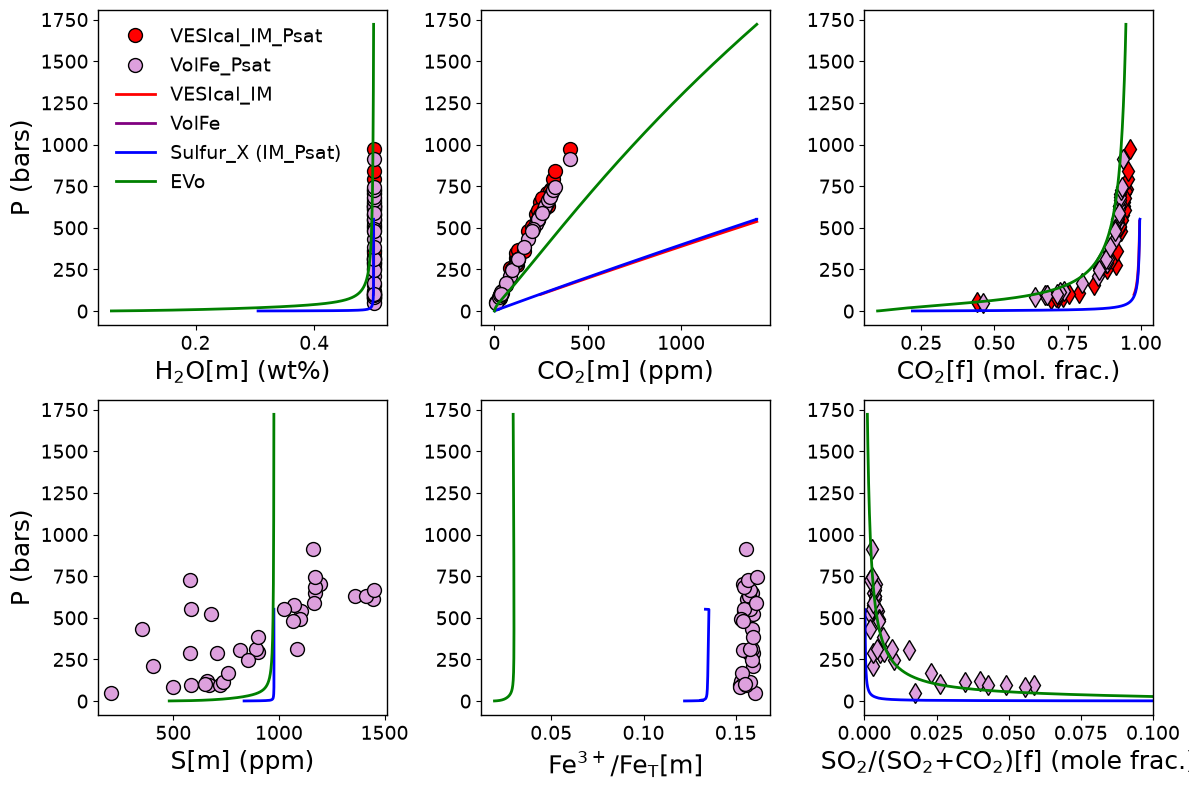

In [ ]:
fig, ((ax1, ax2, ax3),(ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12,8)) # create figure with 2 rows and 3 column panels

# melt compositions as circles, fluid compositions as diamonds

# VESIcal MI results in red from Exercise 1
df = results_pvsat_vc
ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red', label = "VESIcal_IM_Psat")
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'], df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

# VolFe MI results in purple from Exercise 1
df = results_pvsat_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], 'ok', mfc='plum', label = "VolFe_Psat")
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], 'ok', mfc='plum')
ax3.plot(df['xgCO2_mf'], df['P_bar'], 'dk', mfc='plum')
ax4.plot(df['ST_ppmw'], df['P_bar'], 'ok', mfc='plum')
ax5.plot(df['Fe3+/FeT'], df['P_bar'], 'ok', mfc="plum")
ax6.plot(df['xgSO2_mf']/(df['xgCO2_mf']+df['xgSO2_mf']), df['P_bar'], 'dk', mfc='plum')

# DiadFit P + measured FI in orange from Exercise 1
ax6.plot(df_FI['SO2_Burke_table_pref'], results_P_df['P_kbar']*1000, 'dk', mfc='gold')

# VESIcal degassing results from this exercise in red
df = results_degas_vc
ax1.plot(df['H2O_liq'], df['Pressure_bars'], '-', color='red', linewidth=2, label = "VESIcal_IM")
ax2.plot(df['CO2_liq']*10000, df['Pressure_bars'], '-', color='red', linewidth=2)
ax3.plot(df['CO2_fl'], df['Pressure_bars'], '-', color='red', linewidth=2)

# VolFe degassing results from this exercise in purple
df = results_degas_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], '-', color='purple', linewidth=2, label = "VolFe")
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], '-', color='purple', linewidth=2)
ax3.plot(df['xgCO2_mf'], df['P_bar'], '-', color='purple', linewidth=2)
ax4.plot(df['ST_ppmw'], df['P_bar'], '-', color='purple', linewidth=4)
ax5.plot(df['Fe3+/FeT'], df['P_bar'], '-', color='purple', linewidth=4)
ax6.plot(df['xgSO2_mf']/(df['xgCO2_mf']+df['xgSO2_mf']), df['P_bar'], '-', color='purple', linewidth=4)

# Sulfur_X results from this exercise in blue
df = results_degas_sfx
ax1.plot(df['wH2O_melt'], df['pressure']*10., '-', color='blue', linewidth=2, label = "Sulfur_X (IM_Psat)")
ax2.plot(df['wCO2_melt'], df['pressure']*10., '-', color='blue', linewidth=2)
ax3.plot(df['XCO2_fluid'], df['pressure']*10., '-', color='blue', linewidth=2)
ax4.plot(df['wS_melt'], df['pressure']*10., '-', color='blue', linewidth=2)
ax5.plot(df['ferric_ratio'], df['pressure']*10., '-', color='blue', linewidth=2)
ax6.plot(df['XSO2_fluid']/df['XCO2_fluid'], df['pressure']*10., '-', color='blue', linewidth=2)

# EVo results from this exercise in green
df = results_degas_evo
ax1.plot(df['H2O_melt'], df['P'], '-', color='green', linewidth=2, label = "EVo")
ax2.plot(df['CO2_melt']*10000, df['P'], '-', color='green', linewidth=2)
ax3.plot(df['mCO2'], df['P'], '-', color='green', linewidth=2)
ax4.plot(df['Stot_melt']*10000, df['P'], '-', color='green', linewidth=2)
ax5.plot(2*df['F']/(2*df['F']+1), df['P'], '-', color='green', linewidth=2)
ax6.plot(df['mSO2']/(df['mCO2']+df['mSO2']), df['P'], '-', color='green', linewidth=2)

# label axes
ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H$_2$O[m] (wt%)')
ax2.set_xlabel('CO$_2$[m] (ppm)')
ax3.set_xlabel('CO$_2$[f] (mol. frac.)')
ax4.set_ylabel('P (bars)')
ax4.set_xlabel('S[m] (ppm)')
ax5.set_xlabel('Fe$^{3+}$/Fe$_T$[m]')
ax6.set_xlabel('SO$_2$/(SO$_2$+CO$_2$)[f] (mole frac.)')

ax6.set_xlim(0,0.1) # axes range in SO2/SO2+CO2 panel
ax1.legend(frameon=False) # add legend
plt.tight_layout()

## 6. Summary

In this notebook we calculated degassing paths using VESIcal, VolFe, Sulfur_X, and EVo and compared them to pressures and fluid compositions from MI data using VESIcal and VolFe and FI data using DiadFit calculated in <a href="1_Calculate_Pressure_and_Fluid_Composition.ipynb">1. Calculate pressure and fluid composition</a>

For information on how we'd cite such calculations head to <a href="3_Describing_and_Citing_Calculations.ipynb">3. Describing and citing calculations</a>, which also contains the full references for papers mentioned in this notebook.